# Kestirimci Bakım Sınıflandırma Projesi
Amaç:
  - Bu projennin amacı, bir makineden veya endüstriyel ekipmandan gelen sensör verilerini kullanarak ekipmanın sağlıklı(0) mı yoksa arıza yakın(1) durumunda mı olduğunu tahmin eden bir makine öğrenmesi modeli geliştirmek.

Veri seti:
  - Bu projede gerçek dünyayı taklit eden sentetik bir sensör veri seti oluşturalım. Veri setinde tipik kestirimce bakım sensörleri olan:
    - vibration_rms: titreşim rms seviyesi
    - temperature: makine sıcaklığı
    - current: motor akımı
    - vibration_peak: titreşim peak değeri
    - load: yük (%)
  gibi özellikle bulunmaktadır.

Hedef değişken (failure):
  - 0 = Sağlıklı
  - 1 = Arıza yakın

Akış şeması:
1. Gerekli kütüphanelerin yüklenmesi
2. Sentetik veri üretilmesi (veri seti oluşturma)
3. Keşifsel veri analizi ve preprocessing
    - korelasyon
    - train test split
    - standard scaler (ölçeklendirme)
4. Training ve hyperparameter tuning
5. En iyi modelin final eğitimi
6. Değerlendirme: classification report (sınıflandırma raporu) + confusion matrix

In [24]:
# 1. gerekli kütüphanelerin içeriye aktarılması
import numpy as np # sayısal işlem için
import pandas as pd # veri işleme için
import matplotlib.pyplot as plt # görselleştirme
import seaborn as sns # istatistiksel görselleştirme

# sklearn modülleri
from sklearn.model_selection import train_test_split, GridSearchCV # veri bölme - grid search
from sklearn.preprocessing import StandardScaler # normalizasyon
from sklearn.ensemble import RandomForestClassifier # kullanacağımız ml modeli
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay # değerlendirme metrikleri

In [ ]:
# sentetik veri üretimi

In [2]:
np.random.seed(42) # yeniden üretim için sabit random değer
n_samples = 1000 # toplam veri sayısı

In [3]:
# sağlıklı sınıf için sensör dağılımları
vib_rms_healthy = np.random.normal(2,0.5,n_samples // 2)
temp_healthy = np.random.normal(70,6,n_samples // 2)
current_healthy = np.random.normal(9,1.5,n_samples // 2)
peak_healthy = np.random.normal(5,1.2,n_samples // 2)
load_healthy = np.random.normal(60,12,n_samples // 2)

In [4]:
# arızaya yakın sınıfı için sensör dağılımları
vib_rms_fault = np.random.normal(2.4,0.6,n_samples // 2)
temp_fault = np.random.normal(77,7,n_samples // 2)
current_fault = np.random.normal(10,1.6,n_samples // 2)
peak_fault = np.random.normal(6,1.3,n_samples // 2)
load_fault = np.random.normal(68,13,n_samples // 2)

In [5]:
# sağlıklı + arıza sınıflarını birleştir
vibration_rms = np.concatenate([vib_rms_healthy,vib_rms_fault])
temperature = np.concatenate([temp_healthy,temp_fault])
current = np.concatenate([current_healthy,current_fault])
vibration_peak = np.concatenate([peak_healthy,peak_fault])
load = np.concatenate([load_healthy,load_fault])

In [6]:
# hedef değişken
failure = np.array([0]*(n_samples // 2) + [1]*(n_samples // 2))

In [7]:
# dataframe oluştur
df = pd.DataFrame({
    'vibration_rms':vibration_rms,
    'temperature':temperature,
    'current':current,
    'vibration_peak':vibration_peak,
    'load':load,
    'failure':failure
})
df.head(10)

,vibration_rms,temperature,current,vibration_peak,load,failure
0,2.248357,75.557065,11.099033,5.934033,51.897861,0
1,1.930868,81.456500,10.386951,4.338577,58.265776,0
2,2.323844,61.608595,9.089446,4.018161,50.490961,0
3,2.761515,73.377815,8.029595,4.995951,56.304462,0
4,1.882923,66.096145,10.047335,4.795778,37.276624,0
5,1.882932,67.077248,9.590228,4.456126,62.559524,0
6,2.789606,66.445636,10.342790,5.835665,60.014466,0
7,2.383717,64.816055,9.952758,6.146366,50.194936,0
8,1.765263,70.291130,10.574329,5.106088,67.910948,0
9,2.271280,65.014299,8.197147,6.773036,71.250842,0


In [ ]:
# keşifsel veri analizi ve preprocessing

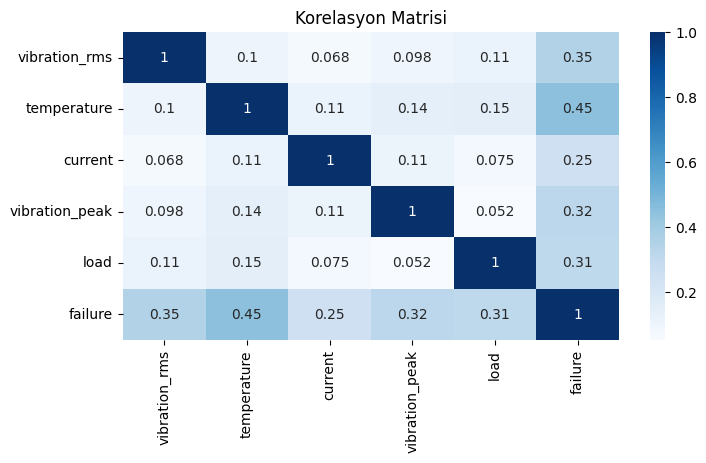

In [10]:
# korelasyon analizi yapalım ve seaborn heat map ile görselleştirelim
plt.figure(figsize = (8,4))
sns.heatmap(df.corr(), annot = True, cmap = "Blues") # korelasyon heatmap
plt.title("Korelasyon Matrisi")
plt.show()

In [11]:
# train ve test split
X = df.drop("failure", axis = 1) # bağımsız değişkenler
y = df["failure"] # hedef değişken

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state=42, stratify = y)

In [13]:
X_train.shape

(750, 5)

In [14]:
X_test.shape

(250, 5)

In [15]:
# scaling ölçeklendirme
# standardization
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train) # eğitim verisini öğren ve dönüştür
X_test_scaled = scaler.transform(X_test)

In [16]:
# hiperparametre tuning
# grid search cross validation

# model: random forest classifier
#   - n_estimators: ağaç sayısı
#   - max_depth: ağaç derinliğimiz
# kaç tane ağaç kullanalım ve bu ağaçların derinliği ne olsun?
# bu parametreleri tek tek deneyelim: hyperparameter tuning yapalım

In [17]:
# grid search sırasında denenecek parametreleri yazalım
param_grid = {
    "n_estimators": [50,100,150], # ağaç sayısı
    "max_depth": [4,6,8,None] # ağaç derinliği
}

"""
n_estimators ve max_depth kombinasyonu
(50,4), (50,6), (50,8), .... (150,None)
"""

'\nn_estimators ve max_depth kombinasyonu\n(50,4), (50,6), (50,8), .... (150,None)\n'

In [18]:
#grid search cross validation yapılanması
grid = GridSearchCV(
    estimator = RandomForestClassifier(random_state = 42), # kullanacağımız model
    param_grid = param_grid, # denenecek parametreler
    cv = 5, # kaç katlı çapraz doğrulama yapacağız
    scoring = "accuracy", # değerlendirme metriği
)

In [19]:
print("grid search cross validationı çalıştır")
grid.fit(X_train_scaled, y_train)
print("grid search cross validationı tamamlandı")

grid search cross validationı çalıştır
grid search cross validationı tamamlandı


In [20]:
# en iyi parametre seti
print(grid.best_params_)

{'max_depth': 6, 'n_estimators': 150}


In [21]:
# en iyi score
print(grid.best_score_)

0.808


In [22]:
# en iyi modeli kullanarak final eğitimi gerçekleştirr
best_model = grid.best_estimator_ # en iyi model
y_pred = best_model.predict(X_test_scaled) # test seti üzerinde yapılan tahmin
y_pred

array([0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1,
       1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0,
       1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0,
       1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0,
       0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1,
       1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1,
       0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0,
       0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1,
       1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0,
       0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1,
       0, 0, 0, 1, 0, 0, 1, 1])

In [23]:
# performans değerlendirme
print("classification report")
print(classification_report(y_test, y_pred))

classification report
              precision    recall  f1-score   support

           0       0.75      0.79      0.77       125
           1       0.78      0.74      0.76       125

    accuracy                           0.76       250
   macro avg       0.76      0.76      0.76       250
weighted avg       0.76      0.76      0.76       250



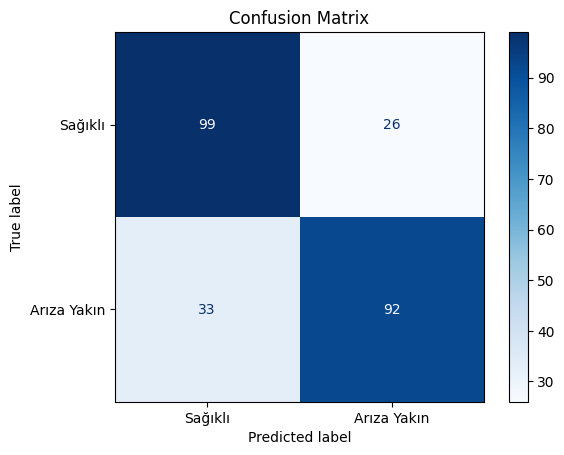

In [25]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = ["Sağıklı", "Arıza Yakın"])
disp.plot(cmap = "Blues") # görsel
plt.title("Confusion Matrix")
plt.show()